In [75]:
import csv
import datetime
import os
import random

import matplotlib.pyplot as plt
import numpy as np
from scipy.io import loadmat
from scipy.optimize import curve_fit, root_scalar, minimize
from scipy.signal import savgol_filter
import h5py

np.set_printoptions(linewidth=100000)

# from data_retrieval import *

import sys
sys.path.insert(0, os.path.abspath('..'))



In [5]:
files = [
    r"Z:\QSimMeasurements\Measurements\8QV1_Q0V\SpecVsFF\SpecVsFF_2026_10_01\SpecVsFF_2026_10_01_18_13_20_Q1.h5",
    r"Z:\QSimMeasurements\Measurements\8QV1_Q0V\SpecVsFF\SpecVsFF_2026_10_01\SpecVsFF_2026_10_01_20_44_48_Q2.h5",
    r"Z:\QSimMeasurements\Measurements\8QV1_Q0V\SpecVsFF\SpecVsFF_2026_10_02\SpecVsFF_2026_10_02_15_27_01_Q3.h5",
    r"Z:\QSimMeasurements\Measurements\8QV1_Q0V\SpecVsFF\SpecVsFF_2026_10_02\SpecVsFF_2026_10_02_01_47_45_Q4.h5",
    r"Z:\QSimMeasurements\Measurements\8QV1_Q0V\SpecVsFF\SpecVsFF_2026_10_02\SpecVsFF_2026_10_02_04_19_12_Q5.h5",
    r"Z:\QSimMeasurements\Measurements\8QV1_Q0V\SpecVsFF\SpecVsFF_2026_10_02\SpecVsFF_2026_10_02_06_50_37_Q6.h5",
    r"Z:\QSimMeasurements\Measurements\8QV1_Q0V\SpecVsFF\SpecVsFF_2026_10_02\SpecVsFF_2026_10_02_09_22_04_Q7.h5",
    r"Z:\QSimMeasurements\Measurements\8QV1_Q0V\SpecVsFF\SpecVsFF_2026_10_02\SpecVsFF_2026_10_02_11_53_32_Q8.h5",
]



Exploring: Z:\QSimMeasurements\Measurements\8QV1_Q0V\SpecVsFF\SpecVsFF_2026_10_01\SpecVsFF_2026_10_01_18_13_20_Q1.h5
├── / (Group)
│   └── [Attributes]
│       ├── Experiment: SpecVsFF
│       ├── Qubit_Readout: [1]
│       ├── config: {"outerFolder": "Z:\\QSimMeasurements\\Measurements\\8QV1_Q0V\\", "res_ch": 8, "qubit_ch": 9, "ro_chs": [0], "fast_flux_chs": [0, 1, 2, 3, 4, 5, 6, 7], "fast_flux_delays": [0, 0, 0, 0, 0, 0, 0, 0], "res_nqz": 1, "qubit_nqz": 2, "mixer_freq": -1750, "qubit_mixer_freq": 4000, "relax_delay": 500, "res_phase": 0, "res_length": 10, "res_LO": 9000, "qubit_LO": 0, "res_gains": [0.055362265763291216], "res_freqs": [-1875.749999999999], "readout_lengths": [3], "adc_trig_delays": [1], "qubit_freqs": [3950], "qubit_gains": [0.22315815174266007], "sigma": 0.05, "FF_Qubits": {"1": {"channel": 0, "Additional_Delay_Time": 0, "Gain_Readout": -18125, "Gain_Pulse": 32000, "Gain_RampInit": -15000, "Gain_Expt": -15000, "Gain_BS": -15000, "Gain_Dynamics": -15000}, "2": {"cha

In [ ]:
from ..

In [21]:
with h5py.File(files[0], 'r') as file:
    ret = file.attrs.keys()
    print(file.attrs['Experiment'])

SpecVsFF


In [4]:
# qubits = [rfsoc_data('0714', '211905', 'FF_vs_Spec', year='2025'),
#           rfsoc_data('0714', '223013', 'FF_vs_Spec', year='2025'),
#           rfsoc_data('0714', '234122', 'FF_vs_Spec', year='2025'),
#           rfsoc_data('0715', '005230', 'FF_vs_Spec', year='2025'),
#           rfsoc_data('0715', '020338', 'FF_vs_Spec', year='2025'),
#           rfsoc_data('0715', '031452', 'FF_vs_Spec', year='2025'),
#           rfsoc_data('0715', '042600', 'FF_vs_Spec', year='2025'),
#           rfsoc_data('0715', '053707', 'FF_vs_Spec', year='2025'),
# ]

qubits = [rfsoc_prefix('0715', 'Q1', 'FF_vs_Spec', year='2025'),
          rfsoc_prefix('0716', 'Q2', 'FF_vs_Spec', year='2025'),
          rfsoc_prefix('0715', 'Q3', 'FF_vs_Spec', year='2025'),
          rfsoc_prefix('0715', 'Q4', 'FF_vs_Spec', year='2025'),
          rfsoc_prefix('0716', 'Q5', 'FF_vs_Spec', year='2025'),
          rfsoc_prefix('0716', 'Q6', 'FF_vs_Spec', year='2025'),
          rfsoc_prefix('0716', 'Q7', 'FF_vs_Spec', year='2025'),
          rfsoc_prefix('0717', 'Q8', 'FF_vs_Spec', year='2025'),
]
qubits = [rfsoc_file(d) for d in qubits]

Z:\QSimMeasurements\Measurements\8QV1_Triangle_lattice\FF_vs_Spec\FF_vs_Spec_2025_07_15\FF_vs_Spec_2025_07_15_17_23_43_Q1.h5
Z:\QSimMeasurements\Measurements\8QV1_Triangle_lattice\FF_vs_Spec\FF_vs_Spec_2025_07_16\FF_vs_Spec_2025_07_16_20_33_21_Q2.h5
Z:\QSimMeasurements\Measurements\8QV1_Triangle_lattice\FF_vs_Spec\FF_vs_Spec_2025_07_15\FF_vs_Spec_2025_07_15_20_23_44_Q3.h5
Z:\QSimMeasurements\Measurements\8QV1_Triangle_lattice\FF_vs_Spec\FF_vs_Spec_2025_07_15\FF_vs_Spec_2025_07_15_21_53_45_Q4.h5
Z:\QSimMeasurements\Measurements\8QV1_Triangle_lattice\FF_vs_Spec\FF_vs_Spec_2025_07_16\FF_vs_Spec_2025_07_16_21_34_50_Q5.h5
Z:\QSimMeasurements\Measurements\8QV1_Triangle_lattice\FF_vs_Spec\FF_vs_Spec_2025_07_16\FF_vs_Spec_2025_07_16_22_36_14_Q6.h5
Z:\QSimMeasurements\Measurements\8QV1_Triangle_lattice\FF_vs_Spec\FF_vs_Spec_2025_07_16\FF_vs_Spec_2025_07_16_23_37_38_Q7.h5
Z:\QSimMeasurements\Measurements\8QV1_Triangle_lattice\FF_vs_Spec\FF_vs_Spec_2025_07_17\FF_vs_Spec_2025_07_17_00_39_04_Q8.h5


In [29]:
def transmon_fit(ff_gain, w_max, w_min, c, ffgain_quantum, zero_voltage_flux):
        flux = ff_gain / ffgain_quantum + zero_voltage_flux

        A = w_max + c
        B = w_min + c
        return (A**4 * np.cos(np.pi*flux)**2 + B**4 * np.sin(np.pi*flux)**2)**0.25 - c

In [80]:
def process_qubit(datafile, ignore_indices, conversion_func, flip_again=False):
    FF = np.asarray(datafile['data']['Gain_Pulse'])
    qfreqs = np.asarray(datafile['data']['qubit_freq_loop'])
    contrast = np.asarray(datafile['data']['contrast'][0])

    
    contrast -= np.mean(contrast)
    if np.abs(np.max(contrast)) < np.abs(np.min(contrast)):
        contrast = - contrast

    if flip_again:
        contrast = - contrast
        
    nyquist_mask = qfreqs > 3450
    qfreqs, contrast = qfreqs[nyquist_mask], contrast[:,nyquist_mask]

    # if j == 7:
        # print('subtracted')
        # contrast -= np.mean(contrast, axis=1).reshape(-1, 1)

    fig, ax = plt.subplots(figsize=(12,6))
    mesh = ax.pcolormesh(FF, qfreqs, contrast.T)
    fig.colorbar(mesh)
    FF, cfreqs, _ = get_center_frequencies(FF, qfreqs, contrast)
    # print(cfreqs)
    cfreqs = np.array([conversion_func(f) for f in cfreqs])
    # print(cfreqs)
    
    ax.scatter(FF,cfreqs,color='red')
    for i in np.arange(len(cfreqs)):
            ax.annotate(str(i), (FF[i], cfreqs[i]),color='white')
    
    params, _ = curve_fit(transmon_fit, np.delete(FF,ignore_indices), np.delete(cfreqs,ignore_indices), [4400, 3400, 180, 64000, 1e-5])
    ax.plot(FF, transmon_fit(FF, *params), color='fuchsia')
    
    ax.set_ylabel("Spec frequency (MHz)")
    ax.set_xlabel("Fast flux gain (DAC max amplitude / 32766)")
    plt.show()

    param_names = ['w_max', 'w_min', 'c', 'ffgain_quantum', 'zero_voltage_flux']
    param_dict = dict(zip(param_names, params))
    print(param_dict)
    print("FQ/2 =", round(param_dict['ffgain_quantum']/2))
    print("FQ =", param_dict['ffgain_quantum'])
    print("found flux =", param_dict['zero_voltage_flux'])

    return param_dict


In [ ]:
qubits = [rfsoc_prefix('0406', 'Q1', 'FF_vs_Spec', 1, year='2026'),
          rfsoc_prefix('0407', 'Q2', 'FF_vs_Spec', 0, year='2026'),
          rfsoc_prefix('0407', 'Q3', 'FF_vs_Spec', 0, year='2026'),
          rfsoc_prefix('0407', 'Q4', 'FF_vs_Spec', 0, year='2026'),
          rfsoc_prefix('0407', 'Q5', 'FF_vs_Spec', 0, year='2026'),
          rfsoc_prefix('0407', 'Q6', 'FF_vs_Spec', 0, year='2026'),
          rfsoc_prefix('0407', 'Q7', 'FF_vs_Spec', 0, year='2026'),
          rfsoc_prefix('0407', 'Q8', 'FF_vs_Spec', 0, year='2026'),
]

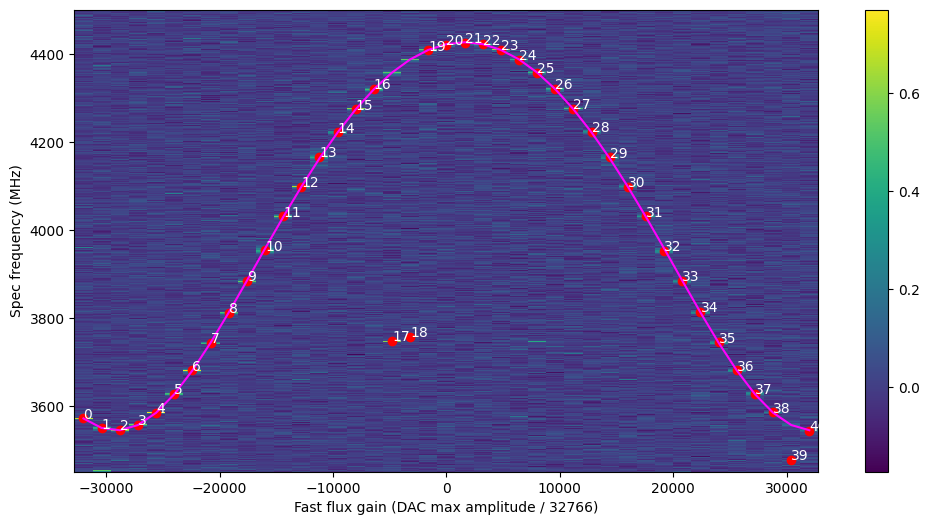

{'w_max': np.float64(4426.583336974098), 'w_min': np.float64(3544.037409049152), 'c': np.float64(-8.932323938701794), 'ffgain_quantum': np.float64(61441.746071366055), 'zero_voltage_flux': np.float64(-0.026123056346500948)}
FQ/2 = 30721
FQ = 61441.746071366055
found flux = -0.026123056346500948


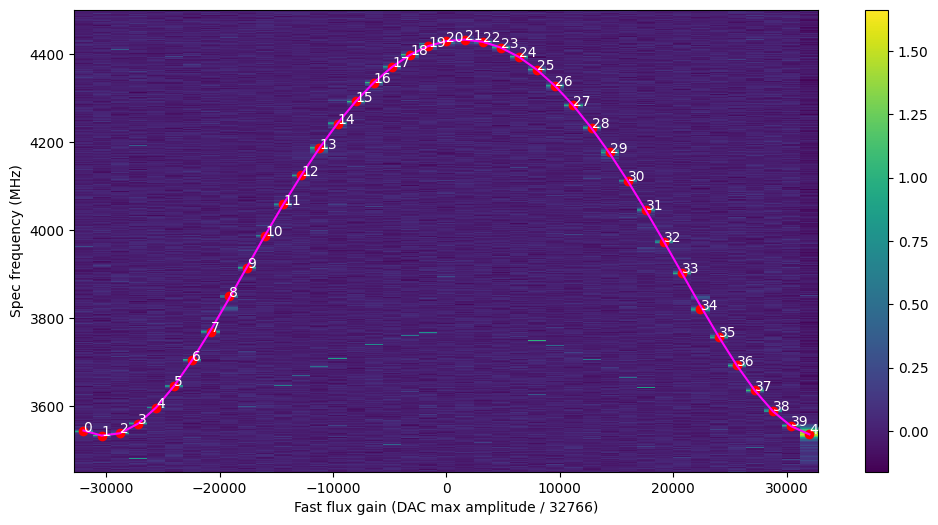

{'w_max': np.float64(4432.674420324717), 'w_min': np.float64(3531.865230029345), 'c': np.float64(-190.83692011822012), 'ffgain_quantum': np.float64(63071.230731808486), 'zero_voltage_flux': np.float64(-0.022796714396409467)}
FQ/2 = 31536
FQ = 63071.230731808486
found flux = -0.022796714396409467


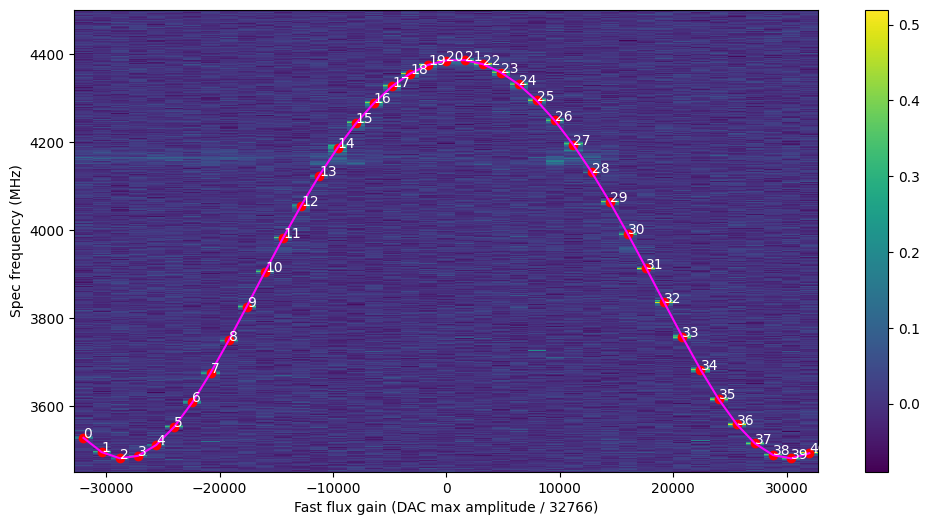

{'w_max': np.float64(4386.911617213641), 'w_min': np.float64(3480.1817873954), 'c': np.float64(-64.08249842374238), 'ffgain_quantum': np.float64(58672.71538690645), 'zero_voltage_flux': np.float64(-0.015190779128162897)}
FQ/2 = 29336
FQ = 58672.71538690645
found flux = -0.015190779128162897


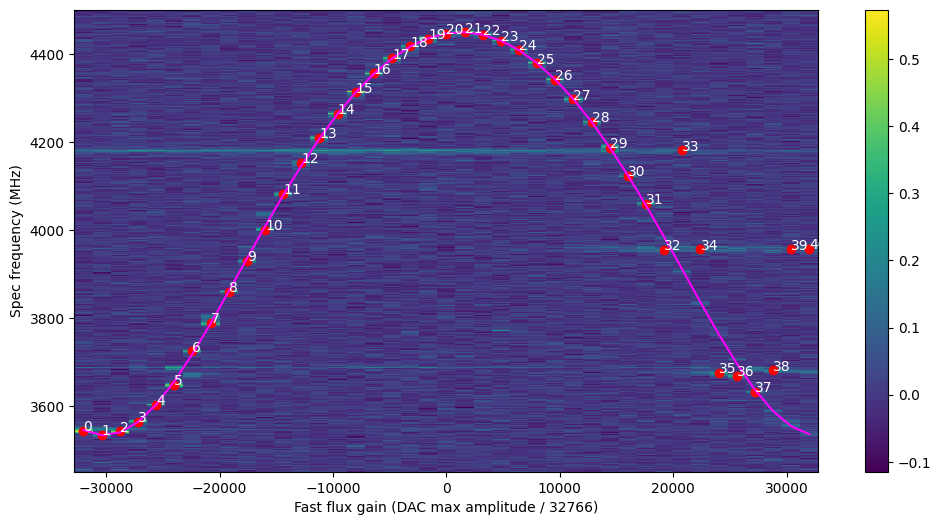

{'w_max': np.float64(4449.513482109323), 'w_min': np.float64(3532.9035866393892), 'c': np.float64(-490.61536126946646), 'ffgain_quantum': np.float64(62983.87801337837), 'zero_voltage_flux': np.float64(-0.021238049642127603)}
FQ/2 = 31492
FQ = 62983.87801337837
found flux = -0.021238049642127603


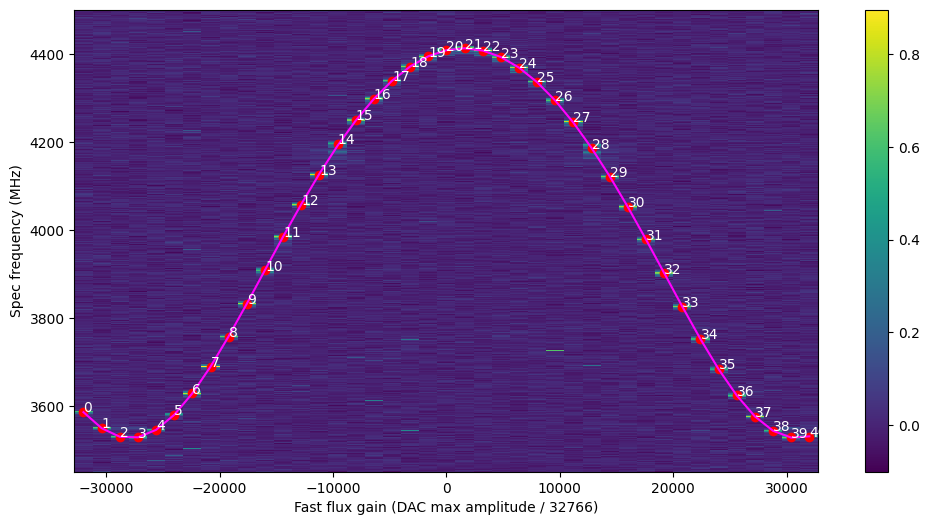

{'w_max': np.float64(4412.927340682641), 'w_min': np.float64(3526.519965820946), 'c': np.float64(61.018244254676866), 'ffgain_quantum': np.float64(58837.17740131096), 'zero_voltage_flux': np.float64(-0.02602745987443241)}
FQ/2 = 29419
FQ = 58837.17740131096
found flux = -0.02602745987443241


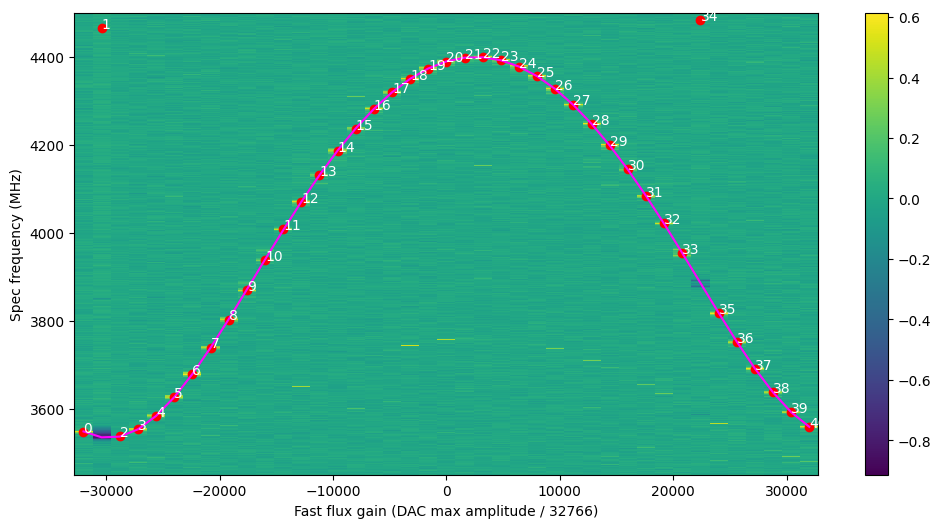

{'w_max': np.float64(4399.842540527643), 'w_min': np.float64(3533.907974113625), 'c': np.float64(-147.24433674067566), 'ffgain_quantum': np.float64(64699.70958414496), 'zero_voltage_flux': np.float64(-0.039856637916178175)}
FQ/2 = 32350
FQ = 64699.70958414496
found flux = -0.039856637916178175


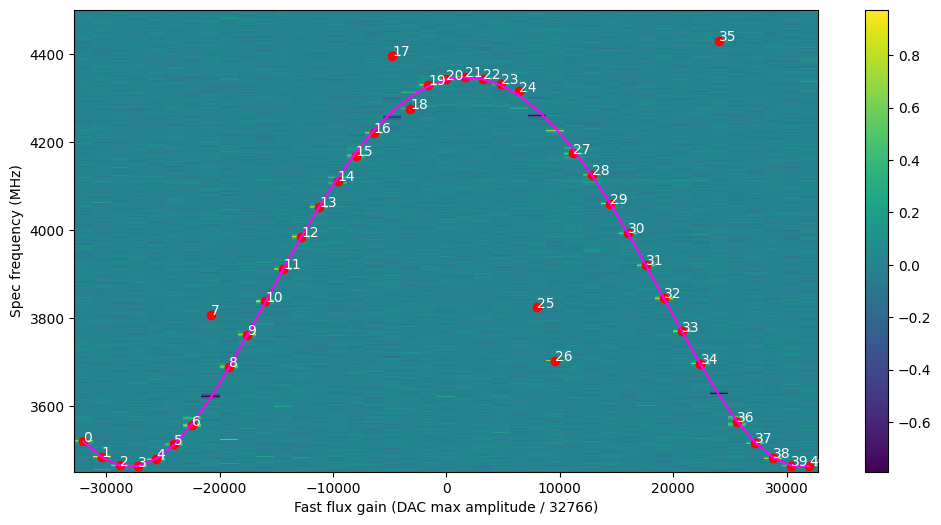

{'w_max': np.float64(4346.815793923483), 'w_min': np.float64(3461.2356263049305), 'c': np.float64(436.63453148745714), 'ffgain_quantum': np.float64(59149.70401797091), 'zero_voltage_flux': np.float64(-0.028796602586253706)}
FQ/2 = 29575
FQ = 59149.70401797091
found flux = -0.028796602586253706


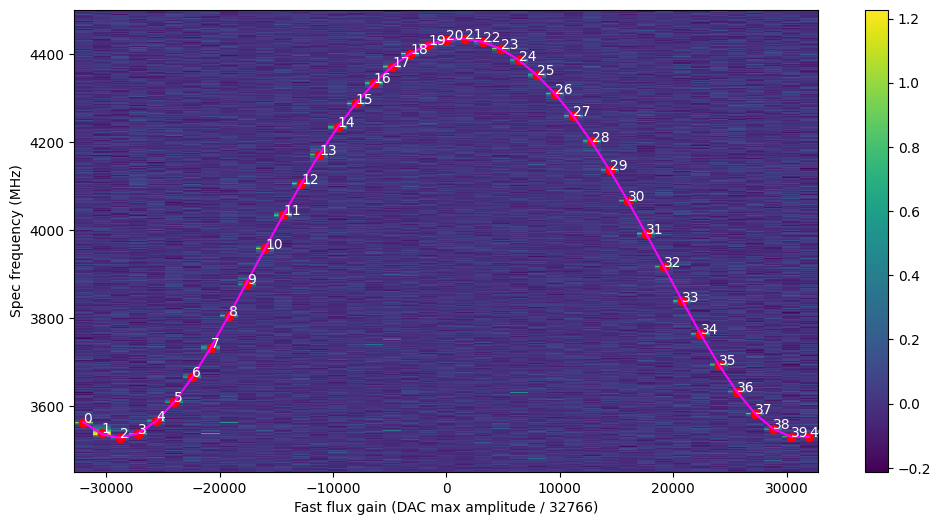

{'w_max': np.float64(4435.048306007066), 'w_min': np.float64(3527.1963934793034), 'c': np.float64(-75.81576301344985), 'ffgain_quantum': np.float64(60030.97590301119), 'zero_voltage_flux': np.float64(-0.019339171011648757)}
FQ/2 = 30015
FQ = 60030.97590301119
found flux = -0.019339171011648757


In [81]:
files = [
    r"Z:\QSimMeasurements\Measurements\8QV1_Q0V\SpecVsFF\SpecVsFF_2026_10_01\SpecVsFF_2026_10_01_18_13_20_Q1.h5",
    r"Z:\QSimMeasurements\Measurements\8QV1_Q0V\SpecVsFF\SpecVsFF_2026_10_01\SpecVsFF_2026_10_01_20_44_48_Q2.h5",
    r"Z:\QSimMeasurements\Measurements\8QV1_Q0V\SpecVsFF\SpecVsFF_2026_10_02\SpecVsFF_2026_10_02_15_27_01_Q3.h5",
    r"Z:\QSimMeasurements\Measurements\8QV1_Q0V\SpecVsFF\SpecVsFF_2026_10_02\SpecVsFF_2026_10_02_01_47_45_Q4.h5",
    r"Z:\QSimMeasurements\Measurements\8QV1_Q0V\SpecVsFF\SpecVsFF_2026_10_02\SpecVsFF_2026_10_02_04_19_12_Q5.h5",
    r"Z:\QSimMeasurements\Measurements\8QV1_Q0V\SpecVsFF\SpecVsFF_2026_10_02\SpecVsFF_2026_10_02_06_50_37_Q6.h5",
    r"Z:\QSimMeasurements\Measurements\8QV1_Q0V\SpecVsFF\SpecVsFF_2026_10_02\SpecVsFF_2026_10_02_09_22_04_Q7.h5",
    r"Z:\QSimMeasurements\Measurements\8QV1_Q0V\SpecVsFF\SpecVsFF_2026_10_02\SpecVsFF_2026_10_02_11_53_32_Q8.h5",
]


qubits = [h5py.File(d) for d in files]

params_list = [None] * 8
ignore = [[17,18,39], [], [], [32,33,34,35,36,37,38,39,40], [], [1,34], [7,17,18,25,26,35], []]

# conversion func: cfreqs - > cfreqs; qubit dressed to bare frequency, for example
conversion_funcs = [lambda t: t] * 8

for j in range(8):
    params_list[j] = process_qubit(qubits[j], ignore[j], conversion_funcs[j], flip_again = (j == 5))

In [85]:
from Device_calib.DeviceData import DeviceData

dev = DeviceData.from_json(r'C:\Users\houck\Documents\HouckLab_QICK\WorkingProjects\triangle_lattice_quench\Device_Calibration\Device_calib\Device_jsons\8QV1_Q0V.json')

In [92]:
# for this calibration, only needed to update ffgain_quantum and zero_voltage_flux
keys = [f'Q{i}' for i in range(1,9)]

for qubit_name, paramd in zip(keys, params_list):
    print(qubit_name, paramd)
    print(dev.transmons[qubit_name].ffgain_quantum)
    dev.transmons[qubit_name].ffgain_quantum = paramd['ffgain_quantum']

    dev.zero_voltage_fluxes[qubit_name] = paramd['zero_voltage_flux']

dev.to_json(r'C:\Users\houck\Documents\HouckLab_QICK\WorkingProjects\triangle_lattice_quench\Device_Calibration\Device_calib\Device_jsons\8QV1_Q0V.json')


Q1 {'w_max': np.float64(4426.583336974098), 'w_min': np.float64(3544.037409049152), 'c': np.float64(-8.932323938701794), 'ffgain_quantum': np.float64(61441.746071366055), 'zero_voltage_flux': np.float64(-0.026123056346500948)}
61441.746071366055
Q2 {'w_max': np.float64(4432.674420324717), 'w_min': np.float64(3531.865230029345), 'c': np.float64(-190.83692011822012), 'ffgain_quantum': np.float64(63071.230731808486), 'zero_voltage_flux': np.float64(-0.022796714396409467)}
64000
Q3 {'w_max': np.float64(4386.911617213641), 'w_min': np.float64(3480.1817873954), 'c': np.float64(-64.08249842374238), 'ffgain_quantum': np.float64(58672.71538690645), 'zero_voltage_flux': np.float64(-0.015190779128162897)}
64000
Q4 {'w_max': np.float64(4449.513482109323), 'w_min': np.float64(3532.9035866393892), 'c': np.float64(-490.61536126946646), 'ffgain_quantum': np.float64(62983.87801337837), 'zero_voltage_flux': np.float64(-0.021238049642127603)}
64000
Q5 {'w_max': np.float64(4412.927340682641), 'w_min': np.

'{\n  "name": "8QV1_0DC",\n  "timestamp": "2026-10-26T10:58:25",\n  "transmons": {\n    "Q1": {\n      "name": "Q1",\n      "role": "Qubit",\n      "w_max": 4409.236725417008,\n      "w_min": 3523.8083204340114,\n      "c": -79.68789695604157,\n      "ffgain_quantum": 61441.746071366055,\n      "Ec": 188,\n      "crosstalk_dc_fq": {\n        "C1": 0.014384835155162208,\n        "C2": -0.010928229344579578,\n        "C3": 0.013052053128042876,\n        "C4": -0.010171992380629928,\n        "C5": 0.01299357527245295,\n        "C6": -0.007993470031716438\n      },\n      "crosstalk_ff_percent": {\n        "Q1": 1.0,\n        "Q2": -0.0055368226531018125,\n        "Q3": 0.011289522457721808,\n        "Q4": -0.005135757378552822,\n        "Q5": 0.010422418477171031,\n        "Q6": -0.004082428884152127,\n        "Q7": 0.006706900324038279,\n        "Q8": -0.002518160078583729\n      }\n    },\n    "Q2": {\n      "name": "Q2",\n      "role": "Qubit",\n      "w_max": 4418.462989819393,\n     

# Caution: Qubit 5 has a strange crossing near 4200!

In [11]:
adjacent_couplers = [(C1,),
 (C2,),
(C1,C3),
 (C2,C4),
(C3,C5),
 (C4,C6),
 (C5,),
 (C6,)]

coupler_index = {C1:8, C2:9, C3:10,C4:11,C5:12,C6:13}

conversion_funcs = []
for j in range(8):
    coupler_freqs = [C.freq(0) for C in adjacent_couplers[j]]
    betas = [BETAS[j,coupler_index[C]] for C in adjacent_couplers[j]]

    print(coupler_freqs)
    print(betas)
    conversion_funcs.append(lambda f: 1000* get_bare_freq(f/1000, coupler_freqs, betas))

conversion_funcs[-1](4500)

[np.float64(5.898142436854608)]
[np.float64(0.026601690774597814)]
[np.float64(5.940392564749256)]
[np.float64(0.027078006040834664)]
[np.float64(5.898142436854608), np.float64(5.865914971910873)]
[np.float64(0.025738919391829745), np.float64(0.025774430135081867)]
[np.float64(5.940392564749256), np.float64(5.927780771240968)]
[np.float64(0.026233846748597474), np.float64(0.026419084036618336)]
[np.float64(5.865914971910873), np.float64(5.852442997911743)]
[np.float64(0.026232281281499303), np.float64(0.025743688235011004)]
[np.float64(5.927780771240968), np.float64(5.955067820188192)]
[np.float64(0.0250463090370899), np.float64(0.026797379106806594)]
[np.float64(5.852442997911743)]
[np.float64(0.02687359563838778)]
[np.float64(5.955067820188192)]
[np.float64(0.02687705497264189)]


np.float64(4513.343365480055)

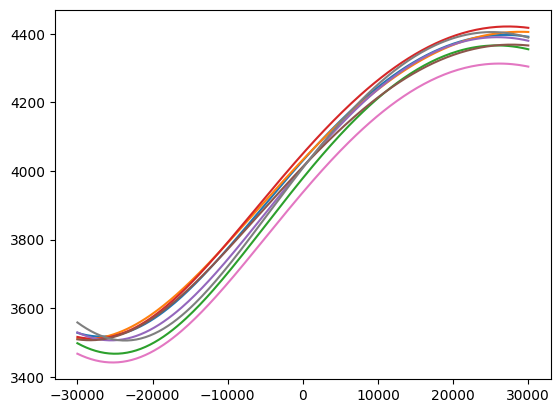

In [26]:
fluxes = np.linspace(-30000, 30000, 200)
for param in params_list:
    plt.plot(fluxes, transmon_fit(fluxes, *param))

In [27]:
params_list

[array([ 2.68812707e+04,  4.27007053e+03,  1.07463469e+05, -1.27006065e+02,  6.30481692e-01]),
 array([2.89289695e+04, 4.43646468e+03, 1.15959433e+05, 3.02838246e+01, 6.36730108e-01]),
 array([2.57922890e+04, 4.47166074e+03, 1.01547325e+05, 1.05315323e+02, 6.38368779e-01]),
 array([ 2.72900802e+04,  4.32660734e+03,  1.10204923e+05, -9.50068119e+01,  6.23439985e-01]),
 array([2.58893624e+04, 4.66361580e+03, 1.02782421e+05, 2.73239662e+02, 6.56844459e-01]),
 array([2.77711931e+04, 4.41303414e+03, 1.12209829e+05, 4.43371271e+01, 6.47527257e-01]),
 array([2.61464137e+04, 4.33191324e+03, 1.02872094e+05, 1.84615899e+01, 6.38100808e-01]),
 array([2.51366119e+04, 4.42135638e+03, 9.75665393e+04, 1.60170432e+01, 6.34533787e-01])]

In [7]:
qubit_params_dir = r'Z:\QSimMeasurements\Measurements\8QV1_Triangle_Lattice\qubit_parameters'

Q1 = np.load(fr'{qubit_params_dir}\old_Q1_popt.npy')
Q2 = np.load(fr'{qubit_params_dir}\old_Q2_popt.npy')
Q3 = np.load(fr'{qubit_params_dir}\old_Q3_popt.npy')
Q4 = np.load(fr'{qubit_params_dir}\old_Q4_popt.npy')
Q5 = np.load(fr'{qubit_params_dir}\old_Q5_popt.npy')
Q6 = np.load(fr'{qubit_params_dir}\old_Q6_popt.npy')
Q7 = np.load(fr'{qubit_params_dir}\old_Q7_popt.npy')
Q8 = np.load(fr'{qubit_params_dir}\old_Q8_popt.npy')

# Q1

In [43]:
for param, Q in zip(params_list, [Q1, Q2, Q3, Q4, Q5, Q6, Q7, Q8]):
    Q1[1], Q[3], Q[4] = param[1] / 1000, param[3]/1000, param[4]

[[0.      0.00161 0.00061 0.      0.      0.      0.      0.      0.0266  0.      0.      0.      0.      0.     ]
 [0.00161 0.      0.00168 0.00061 0.      0.      0.      0.      0.      0.02708 0.      0.      0.      0.     ]
 [0.00061 0.00168 0.      0.0016  0.00061 0.      0.      0.      0.02574 0.      0.02577 0.      0.      0.     ]
 [0.      0.00061 0.0016  0.      0.00164 0.00061 0.      0.      0.      0.02623 0.      0.02642 0.      0.     ]
 [0.      0.      0.00061 0.00164 0.      0.00162 0.00061 0.      0.      0.      0.02623 0.      0.02574 0.     ]
 [0.      0.      0.      0.00061 0.00162 0.      0.00167 0.00061 0.      0.      0.      0.02505 0.      0.0268 ]
 [0.      0.      0.      0.      0.00061 0.00167 0.      0.00163 0.      0.      0.      0.      0.02687 0.     ]
 [0.      0.      0.      0.      0.      0.00061 0.00163 0.      0.      0.      0.      0.      0.      0.02688]
 [0.0266  0.      0.02574 0.      0.      0.      0.      0.      0.      0.    

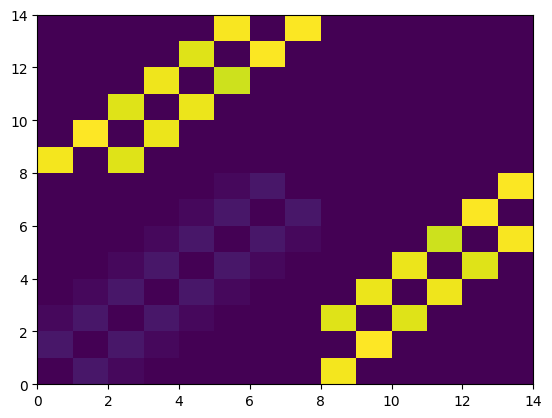

In [10]:
BETAS = np.load(fr'{qubit_params_dir}\betas.npy')
np.set_printoptions(linewidth=100000)
print(np.round(BETAS, 5))
plt.pcolormesh(BETAS)

In [8]:
C1 = Transmon(np.load(fr'{qubit_params_dir}\C1_popt.npy'), 'C1')
C2 = Transmon(np.load(fr'{qubit_params_dir}\C2_popt.npy'), 'C2')
C3 = Transmon(np.load(fr'{qubit_params_dir}\C3_popt.npy'), 'C3')
C4 = Transmon(np.load(fr'{qubit_params_dir}\C4_popt.npy'), 'C4')
C5 = Transmon(np.load(fr'{qubit_params_dir}\C5_popt.npy'), 'C5')
C6 = Transmon(np.load(fr'{qubit_params_dir}\C6_popt.npy'), 'C6')


TODO:
Update dictionary file with coupler fits, as well as qubits with disentangled couplers.